In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [63]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, add
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm_notebook
from collections import Counter

# you should change the image directory path , and captions path

In [ ]:

images_directory = r"C:\Users\Pro\Downloads\dataset1\images\\"

captions_path = r'C:\Users\Pro\Downloads\dataset1\captions.txt'


In [65]:
def load_captions(file_path):
    with open(file_path, 'r') as f:
        captions = f.readlines()
        captions = [caption.lower() for caption in captions[1:]]
    return captions

def tokenize_captions(captions):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(captions)
    return tokenizer


In [66]:
captions

['1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set of stairs in an entry way .\n',
 '1000268201_693b08cb0e.jpg,a girl going into a wooden building .\n',
 '1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse .\n',
 '1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playhouse .\n',
 '1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a wooden cabin .\n',
 '1001773457_577c3a7d70.jpg,a black dog and a spotted dog are fighting\n',
 '1001773457_577c3a7d70.jpg,a black dog and a tri-colored dog playing with each other on the road .\n',
 '1001773457_577c3a7d70.jpg,a black dog and a white dog with brown spots are staring at each other in the street .\n',
 '1001773457_577c3a7d70.jpg,two dogs of different breeds looking at each other on the road .\n',
 '1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other .\n',
 '1002674143_1b742ab4b8.jpg,a little girl covered in paint sits in front of a painted rainbow 

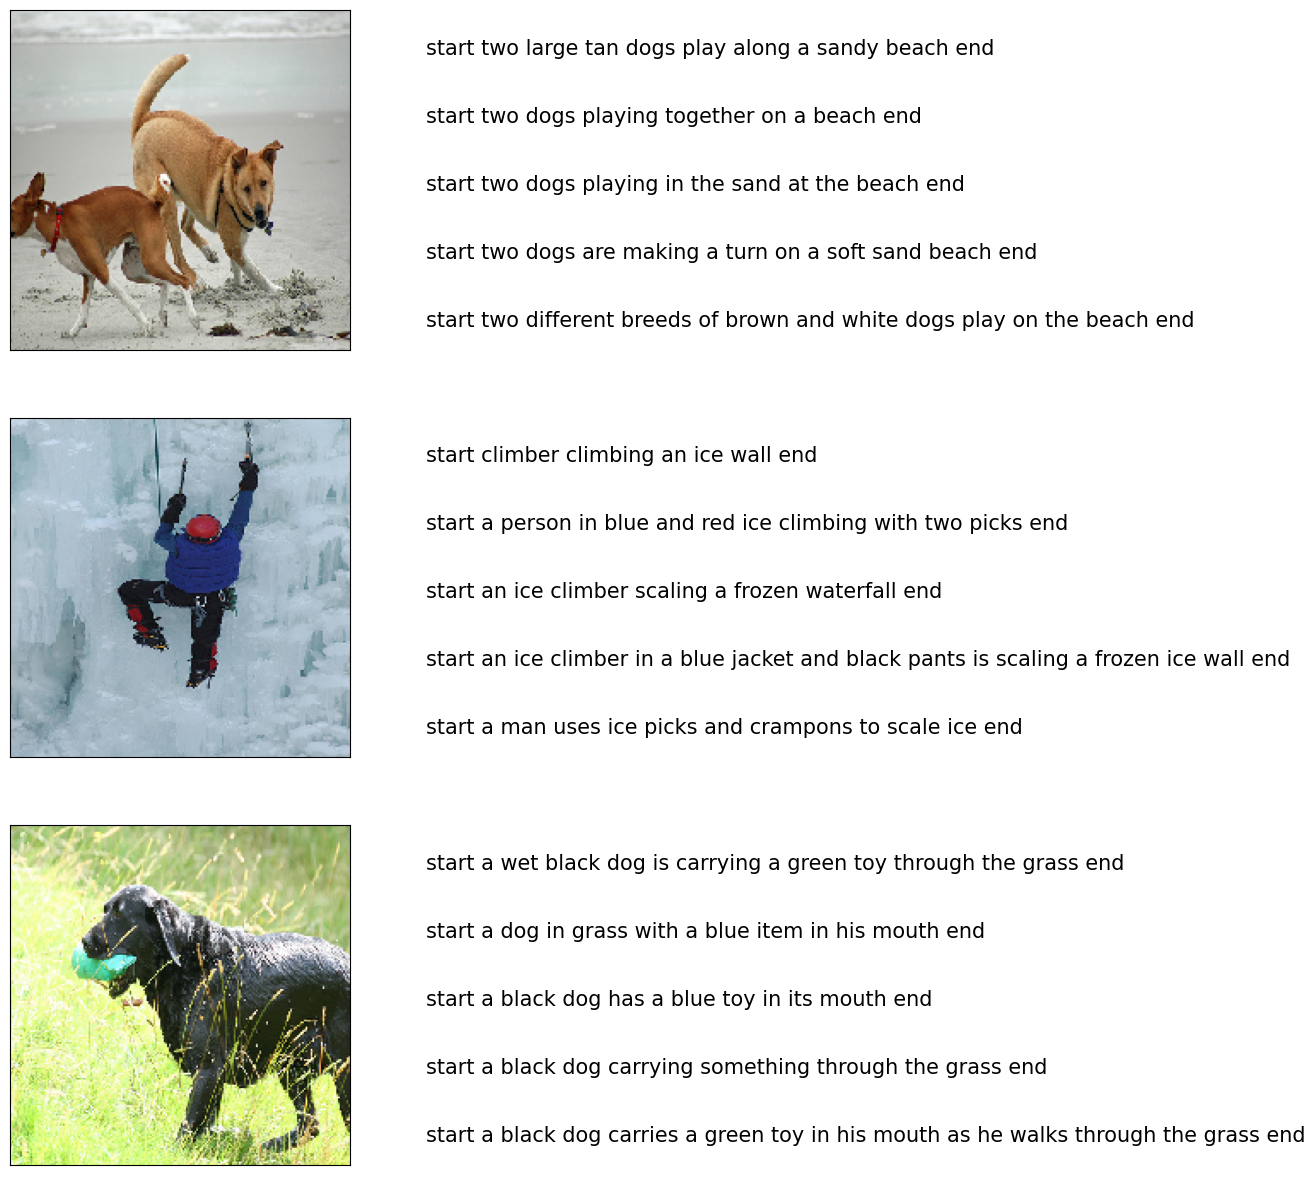

In [67]:
def visualaization(data, num_of_images):
    captions_dictionary = {}
    rows_needed = num_of_images * 5     

    for item in data[100:100 + rows_needed]:
        image_id, caption = item.split('\t')

        if image_id not in captions_dictionary:
            captions_dictionary[image_id] = []
        captions_dictionary[image_id].append(caption)

    fig = plt.figure(figsize=(10, 15))
    count = 1

    for filename, captions in captions_dictionary.items():
        image_load = load_img(images_directory + filename,
                              target_size=(199, 199, 3))

        ax = fig.add_subplot(num_of_images, 2, count, xticks=[], yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images, 2, count)
        plt.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, len(captions))

        for i, caption in enumerate(captions):
            ax.text(0, i, caption, fontsize=15)

        count += 1

    plt.show()


visualaization(captions_IDs, 3)


In [68]:
import re
captions_IDs = []
for i in range(len(cleaned_captions)):
    item = captions[i].split(',')[0]+'\t'+'start '+cleaned_captions[i]+' end\n'
    captions_IDs.append(item)
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
    
cleaned_captions = [clean_text(caption.split(',')[1]) for caption in captions]
cleaned_captions

['a child in a pink dress is climbing up a set of stairs in an entry way',
 'a girl going into a wooden building',
 'a little girl climbing into a wooden playhouse',
 'a little girl climbing the stairs to her playhouse',
 'a little girl in a pink dress going into a wooden cabin',
 'a black dog and a spotted dog are fighting',
 'a black dog and a tricolored dog playing with each other on the road',
 'a black dog and a white dog with brown spots are staring at each other in the street',
 'two dogs of different breeds looking at each other on the road',
 'two dogs on pavement moving toward each other',
 'a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl',
 'a little girl is sitting in front of a large painted rainbow',
 'a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it',
 'there is a girl with pigtails sitting in front of a rainbow painting',
 'young girl with pigtails painting outside in the grass',

# wordcloud

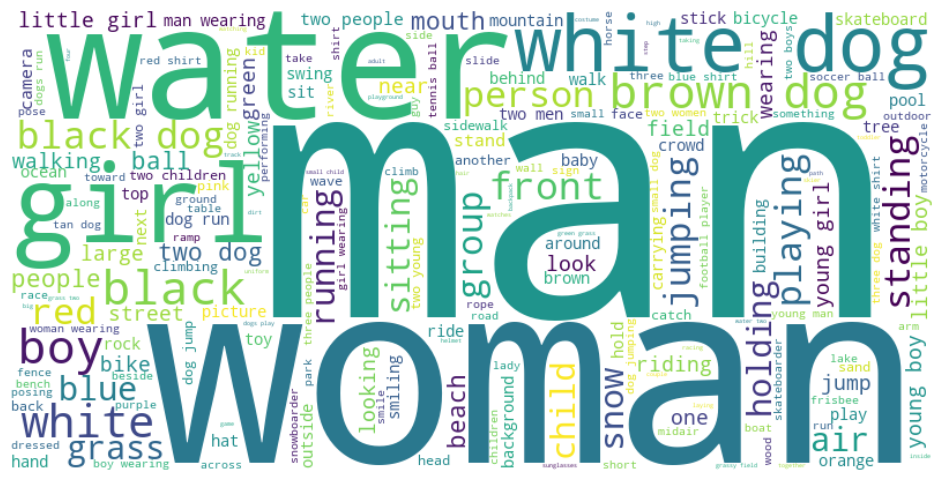

In [69]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = " ".join(cleaned_captions)   

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


In [70]:
tokenizer = tokenize_captions(cleaned_captions)
vocab_size = len(tokenizer.word_index) + 1
vocab_size

8586

In [71]:
all_image_ids = os.listdir(images_directory)
train_image_ids, val_image_ids = train_test_split(all_image_ids, test_size=0.15, random_state=42)
val_image_ids, test_image_ids = train_test_split(val_image_ids, test_size=0.1, random_state=42)
train_captions, val_captions, test_captions = [], [], []


In [72]:
for caption in captions_IDs:
    image_id, _ = caption.split('\t')
    if image_id in train_image_ids:
        train_captions.append(caption)
    elif image_id in val_image_ids:
        val_captions.append(caption)
    elif image_id in test_image_ids:
        test_captions.append(caption)

In [73]:
train_captions[0]

'1000268201_693b08cb0e.jpg\tstart a child in a pink dress is climbing up a set of stairs in an entry way end\n'

In [74]:
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img

def extract_image_features(model, image_path):
    img = preprocess_image(image_path)
    features = model.predict(img, verbose=0)
    return features

inception_v3_model = InceptionV3(weights = 'imagenet', input_shape=(299, 299, 3))
inception_v3_model.layers.pop()
inception_v3_model = Model(inputs=inception_v3_model.inputs, outputs=inception_v3_model.layers[-2].output)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


#  Extracting features

In [75]:
train_image_features, val_image_features, test_image_features = {}, {}, {}  # A Dictionary to store image features with their corresponding IDs

pbar = tqdm_notebook(total=len(all_image_ids), position=0, leave=True, colour='green')

for caption in all_image_ids:
    image_id = caption.split('\t')[0]
    image_path = os.path.join(images_directory, image_id)
    image_features = extract_image_features(inception_v3_model, image_path) # Extracting features

    if image_id in train_image_ids:
        train_image_features[image_id] = image_features.flatten()  # Flattening the features
        pbar.update(1)

    elif image_id in val_image_ids:
        val_image_features[image_id] = image_features.flatten()  # Flattening the features
        pbar.update(1)

    elif image_id in test_image_ids:
        test_image_features[image_id] = image_features.flatten()  # Flattening the features
        pbar.update(1)

    else:
        print('Unknown image ID !')

pbar.close()

  0%|          | 0/8091 [00:00<?, ?it/s]

In [95]:
def data_generator(captions, image_features, tokenizer, max_caption_length, batch_size):
    num_samples = len(captions)
    image_ids = list(image_features.keys())
    while True:
        np.random.shuffle(image_ids)  # Shuffle image_ids for each epoch
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            X_images, X_captions, y = [], [], []
            for caption in captions[start_idx:end_idx]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.rstrip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # Tokenizing the caption
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # X_caption, Y
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X_images.append(image_features[image_id])
                    X_captions.append(in_seq)
                    y.append(out_seq)

            yield (np.array(X_images), np.array(X_captions)), np.array(y)



max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 1

cnn_output_dim = inception_v3_model.output_shape[1] # 2048

batch_size_train = 270
batch_size_val = 150

train_data_generator = data_generator(train_captions, train_image_features, tokenizer, max_caption_length, batch_size_train)
val_data_generator = data_generator(val_captions, val_image_features, tokenizer, max_caption_length, batch_size_val)

# Model

In [123]:
def build_model(vocab_size, max_caption_length, cnn_output_dim):
    input_image = Input(shape=(cnn_output_dim,), name='Features_Input')
    fe1 = BatchNormalization()(input_image)
    fe2 = Dense(256, activation='relu')(fe1) # Adding a Dense layer to the CNN output to match the decoder output size
    fe3 = BatchNormalization()(fe2)

    input_caption = Input(shape=(max_caption_length,), name='Sequence_Input')
    se1 = Embedding(vocab_size, 256, mask_zero=True)(input_caption)
    se2 = LSTM(256)(se1)

    decoder1 = add([fe3, se2])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax', name='Output_Layer')(decoder2)

    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Captioning')
    return model

caption_model = build_model(vocab_size, max_caption_length, cnn_output_dim)

optimizer = Adam(learning_rate=0.01, clipnorm=1.0)
caption_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

caption_model.summary()


Model: "Image_Captioning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Features_Input (InputLayer)   │ (None, 2048)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_114       │ (None, 2048)              │           8,192 │ Features_Input[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Sequence_Input (InputLayer)   │ (None, 34)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_20 (Dense)              │ (None, 256)               │         524,544 │ batch_normalization_114[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_10 (Embedding)      │ (None, 34, 256)           │       2,198,016 │ Sequence_Input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_11 (NotEqual)       │ (None, 34)                │               0 │ Sequence_Input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_115       │ (None, 256)               │           1,024 │ dense_20[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_10 (LSTM)                │ (None, 256)               │         525,312 │ embedding_10[0][0],        │
│                               │                           │                 │ not_equal_11[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_10 (Add)                  │ (None, 256)               │               0 │ batch_normalization_115[0… │
│                               │                           │                 │ lstm_10[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_21 (Dense)              │ (None, 256)               │          65,792 │ add_10[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Output_Layer (Dense)          │ (None, 8586)              │       2,206,602 │ dense_21[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 5,529,482 (21.09 MB)

 Trainable params: 5,524,874 (21.08 MB)

 Non-trainable params: 4,608 (18.00 KB)

# Training

In [101]:
caption_model = build_model(vocab_size, max_caption_length, cnn_output_dim)

optimizer = Adam(learning_rate=0.01, clipnorm=1.0)
caption_model.compile(loss='categorical_crossentropy', optimizer=optimizer)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

import math
def lr_scheduler(epoch, lr):
    return lr * math.exp(-0.2)

lr_schedule = LearningRateScheduler(lr_scheduler)

history = caption_model.fit(
    train_data_generator,
    steps_per_epoch=len(train_captions) // batch_size_train,
    validation_data=val_data_generator,
    validation_steps=len(val_captions) // batch_size_val,
    epochs=15,
    callbacks=[early_stopping, lr_schedule]
)

caption_model.save("caption_model1.keras")
print("model saved!")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("max_len.txt", "w") as f:
    f.write(str(max_caption_length))


Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 431s 3s/step - loss: 5.1324 - val_loss: 3.7546 - learning_rate: 0.0082
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 502s 4s/step - loss: 3.4226 - val_loss: 3.3615 - learning_rate: 0.0067
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 469s 4s/step - loss: 2.9773 - val_loss: 3.2747 - learning_rate: 0.0055
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 465s 4s/step - loss: 2.7061 - val_loss: 3.2951 - learning_rate: 0.0045
Epoch 5/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 453s 4s/step - loss: 2.4873 - val_loss: 3.3346 - learning_rate: 0.0037
Epoch 6/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 450s 4s/step - loss: 2.3061 - val_loss: 3.4213 - learning_rate: 0.0030
Epoch 7/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 449s 4s/step - loss: 2.1509 - val_loss: 3.4839 - learning_rate: 0.0025
Epoch 8/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 454s 4s/step - loss: 2.0189 - val_loss: 3.5517 - learning_rate: 0.0020
model saved!


# Load the model , tokenizer , max length 

In [127]:
from tensorflow.keras.models import load_model
import pickle

from keras.saving import load_model

caption_model = load_model("caption_model1.keras")
# load model
#caption_model = load_model("caption_model.h5")

# load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# load max length
with open("max_len.txt", "r") as f:
    max_caption_length = int(f.read())


In [128]:
def extract_feature_from_new_image(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    features = inception_v3_model.predict(img, verbose=0)
    return features.flatten()


# With  greedy

In [129]:
def predict_caption_greedy(image_path):
    image_feature = extract_feature_from_new_image(image_path)  # (2048,)
    
    in_text = "start"
    for _ in range(max_caption_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_caption_length)
        yhat = caption_model.predict([image_feature.reshape(1, -1), sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += " " + word
        if word == 'end':
            break
    
    result = in_text.replace("start ", "").replace(" end", "")
    return result


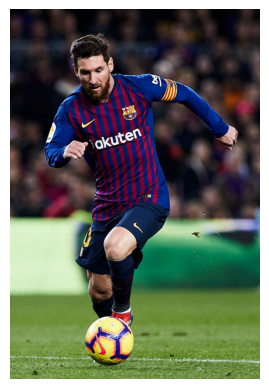

In [131]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "messi1.jpg"

# display image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()


In [158]:
caption = predict_caption_greedy("messi.jpg")
print("caption:", caption)


caption: a boy in a red shirt is playing soccer


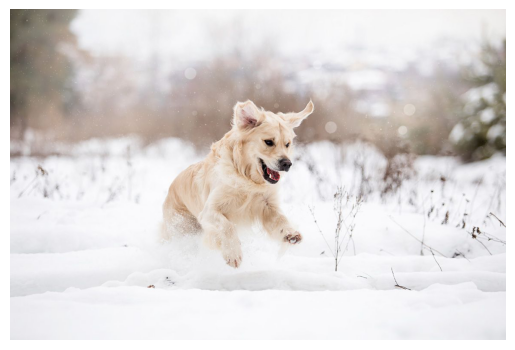

In [159]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "doginsnoww.jpg"

# display image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()


In [160]:
caption = predict_caption_greedy("doginsnoww.jpg")
print("caption:", caption)


caption: a dog running in the snow


# With beam

In [118]:
def predict_caption_beam_search(image_path, K_beams=3, log=False):
    image_feature = extract_feature_from_new_image(image_path)  # (2048,)

    start = [tokenizer.word_index['start']]
    start_word = [[start, 0.0]]

    for _ in range(max_caption_length):
        temp = []
        for s in start_word:
            sequence = pad_sequences([s[0]], maxlen=max_caption_length)
            preds = caption_model.predict([image_feature.reshape(1, -1), sequence], verbose=0)
            word_preds = np.argsort(preds[0])[-K_beams:]

            for w in word_preds:
                next_cap = s[0].copy()
                next_cap.append(w)
                # prob add
                if log:
                    prob = s[1] + np.log(preds[0][w])
                else:
                    prob = s[1] + preds[0][w]
                temp.append([next_cap, prob])

        start_word = sorted(temp, key=lambda x: x[1])[-K_beams:]

    final_seq = start_word[-1][0]
    final_caption = []
    for idx in final_seq:
        word = tokenizer.index_word[idx]
        if word == 'start':
            continue
        if word == 'end':
            break
        final_caption.append(word)

    return " ".join(final_caption)


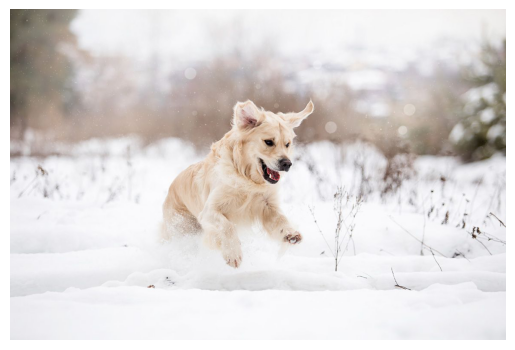

In [139]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "doginsnoww.jpg"

# display image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()


In [138]:
caption = predict_caption_beam_search("doginsnoww.jpg", K_beams=5)
print("beam search caption:", caption)


beam search caption: a tan dog is running in the snow


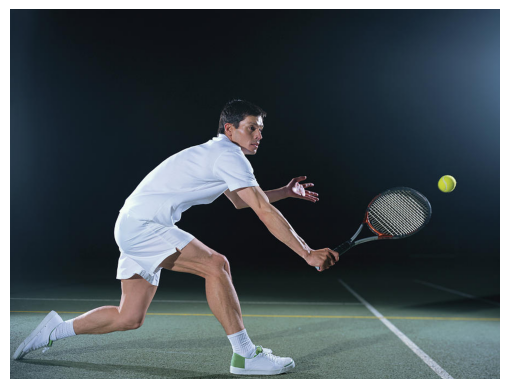

In [153]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "tennis.jpg"

# display image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()


In [152]:
caption = predict_caption_beam_search("tennis.jpg", K_beams=5)
print("beam search caption:", caption)


beam search caption: a young boy plays with a tennis ball
